# Working with Complex Data Types & VMaps

## Setup

In order to work with complex data types in VerticaPy, you'll need to complete the following three setup tasks: 

<ul class="ul_content">
<li>Import relevant libraries:</li>
</ul>

In [1]:
import verticapy as vp

<ul class="ul_content">
<li>Connect to Vertica:</li>
</ul>

In [ ]:
vp.new_connection({"host": "10.211.55.14", 
                   "port": "5433", 
                   "database": "testdb", 
                   "password": "XxX", 
                   "user": "dbadmin"},
                   name = "Vertica_New_Connection")

<ul class="ul_content">
<li>Check your VerticaPy version to make sure you have access to the right functions:</li>
</ul>

In [2]:
vp.__version__

'0.11.0'

You can make it easier to keep track of your work by creating a custom schema:
<br><b>Note:</b> Because some tables are repeated in this demonstration, tables with the same names are dropped.

In [3]:
vp.drop("complex_vmap_test", method = "schema")
vp.create_schema("complex_vmap_test")

True

We also set the path to our data:

In [ ]:
path= "/home/dbadmin/"

You can download the demo datasets by clicking <a href="datasets.zip">here</a>.

## Loading Complex Data

There are two ways to load a nested data file:

<ul class="ul_content">
<li><b>Load directly using <a href="../../../documentation_last/utilities/read_json/index.php">read_json</a></b>. In this case, you will need to use an additional parameter to identify all the data types. The function loads the data using flex tables and VMaps (Native Vertica MAPS, which are flexible but not optimally performant).</li>
<li><b>Load using <a href="../../../documentation_last/utilities/read_file/index.php">read_file</a></b>. The function preidcts the complex data structure.</li>
</ul>

Let's try both:

,123away_scoreInt,"🛠Row(away_team_gender varchar(80),away_team_group varchar(80),away_team_id int,away_team_name varchar(80),country row(id int,name","🛠Row(competition_id int,competition_name varchar(80),country_name varchar(80))","🛠Row(id int,name varchar(80))",123home_scoreInt,"🛠Row(country row(id int,name varchar(80)),home_team_gender varchar(80),home_team_group varchar(80),home_team_id int,home_team_nam",📅kick_offTime,📅last_updatedDate,📅match_dateDate,123match_idInt,Abcmatch_statusVarchar(80),123match_weekInt,"🛠Row(data_version date,shot_fidelity_version int,xy_fidelity_version int)","🛠Row(season_id int,season_name varchar(80))"
1,0,,,,1,,19:00:00,2019-12-16,2008-08-31,69147,available,1,,
2,0,,,,2,,20:00:00,2019-12-16,2009-03-07,69216,available,26,,
3,0,,,,2,,20:00:00,2019-12-16,2009-04-11,69222,available,30,,
4,0,,,,5,,20:00:00,2019-12-16,2009-01-17,69183,available,19,,
5,0,,,,5,,22:00:00,2019-12-16,2008-10-25,69232,available,8,,
6,0,,,,6,,19:00:00,2019-12-16,2009-03-22,69142,available,28,,
7,1,,,,0,,20:00:00,2019-12-16,2009-04-04,69273,available,29,,
8,2,,,,0,,21:00:00,2019-12-16,2008-11-16,69285,available,11,,
9,2,,,,1,,17:00:00,2019-12-16,2009-02-01,69209,available,21,,
10,4,,,,1,,20:00:00,2019-12-16,2008-11-01,69235,available,9,,

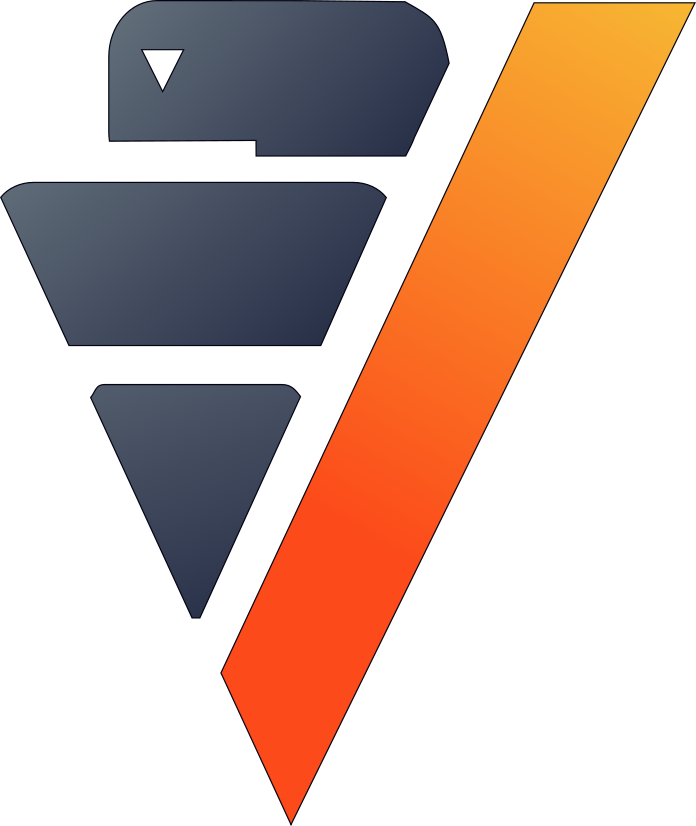

In [4]:
import verticapy as vp
data = vp.read_json(path + "laliga/2008.json",
                    schema = "public",
                    ingest_local = False,
                    use_complex_dt = True,)

Similar to the use of <a href="../../../documentation_last/utilities/read_json/index.php">read_json</a> above, we can use <a href="../../../documentation_last/utilities/read_file/index.php">read_file</a> to ingest the complex data directly:

,123away_scoreInt,"🛠Row(away_team_gender varchar(80),away_team_group varchar(80),away_team_id int,away_team_name varchar(80),country row(id int,name","🛠Row(competition_id int,competition_name varchar(80),country_name varchar(80))","🛠Row(id int,name varchar(80))",123home_scoreInt,"🛠Row(country row(id int,name varchar(80)),home_team_gender varchar(80),home_team_group varchar(80),home_team_id int,home_team_nam",📅kick_offTime,📅last_updatedDate,📅match_dateDate,123match_idInt,Abcmatch_statusVarchar(80),123match_weekInt,"🛠Row(data_version date,shot_fidelity_version int,xy_fidelity_version int)","🛠Row(season_id int,season_name varchar(80))"
1,0,,,,3,,22:00:00,2019-12-16,2005-10-22,68318,available,8,,
2,1,,,,2,,19:00:00,2019-12-16,2006-01-15,68342,available,19,,
3,1,,,,5,,22:00:00,2019-12-16,2006-02-18,69172,available,24,,
4,3,,,,1,,21:00:00,2019-12-16,2005-11-06,68339,available,10,,
5,0,,,,2,,19:00:00,2019-12-16,2006-01-22,68324,available,20,,
6,0,,,,2,,20:30:00,2019-12-16,2005-10-26,69164,available,11,,
7,1,,,,2,,21:00:00,2020-02-27,2005-12-11,68321,available,15,,
8,2,,,,1,,22:00:00,2019-12-16,2006-01-07,68348,available,18,,
9,2,,,,2,,20:00:00,2019-12-16,2005-10-01,68317,available,6,,
10,3,,,,1,,22:00:00,2019-12-16,2005-12-17,68322,available,16,,

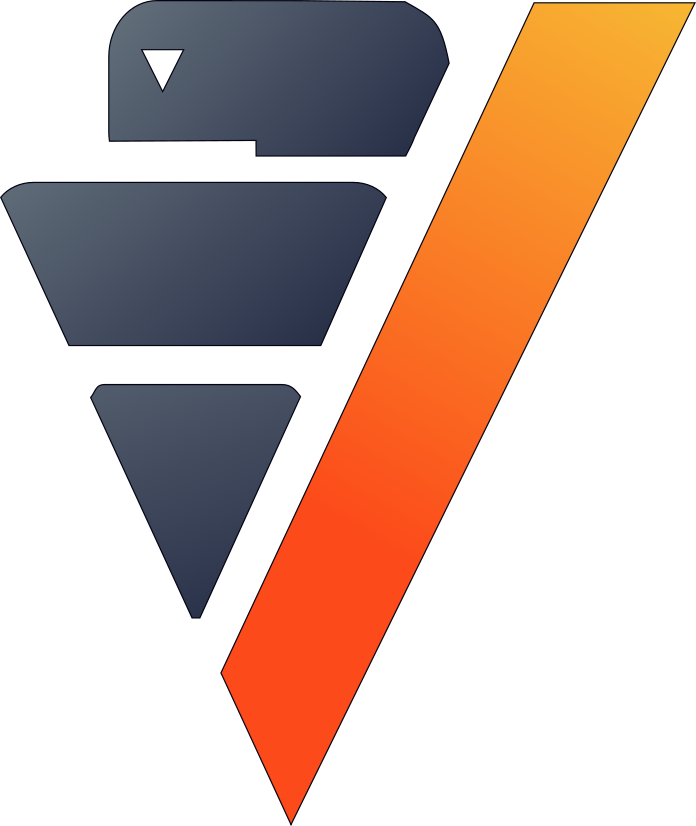

In [6]:
data = vp.read_file(path = path + "laliga/2005.json",
                    ingest_local = False,
                    schema = "complex_vmap_test",)
data

We can also use the handy 'genSQL' parameter to generate (but not execute) the SQL needed to create the final relation:
<br><b>Note:</b> This is a great way to customize the data ingestion or alter the final relation types.

In [9]:
sql = vp.read_file(path = path + "laliga/2005.json",
                   schema = "complex_vmap_test",
                   table_name = "laliga_2005",
                   genSQL = True,
                   varchar_varbinary_length = 60,
                   ingest_local = False,
                   dtype = {"away_score": "float"})
for query in sql:
    print(query)

CREATE TABLE "complex_vmap_test"."laliga_2005"("away_score" float, "away_team" Row("away_team_gender" varchar(60), "away_team_group" varchar(60), "away_team_id" int, "away_team_name" varchar(60), "country" Row("id" int, "name" varchar(60))), "competition" Row("competition_id" int, "competition_name" varchar(60), "country_name" varchar(60)), "competition_stage" Row("id" int, "name" varchar(60)), "home_score" int, "home_team" Row("country" Row("id" int, "name" varchar(60)), "home_team_gender" varchar(60), "home_team_group" varchar(60), "home_team_id" int, "home_team_name" varchar(60)), "kick_off" time, "last_updated" date, "match_date" date, "match_id" int, "match_status" varchar(60), "match_week" int, "metadata" Row("data_version" date, "shot_fidelity_version" int, "xy_fidelity_version" int), "season" Row("season_id" int, "season_name" varchar(60)))
copy "complex_vmap_test"."laliga_2005" from '/scratch_b/qa/ericsson/laliga/2005.json' PARSER FJsonParser()


## Feature Exploration

<a id='row_cell'></a>
In the generated SQL from the above example, we can see that the away_team column is a ROW type with a complex structure consisting of many sub-columns. We can convert this column into a JSON and view its contents:

,123away_scoreInt,"🛠Row(away_team_gender varchar(80),away_team_group varchar(80),away_team_id int,away_team_name varchar(80),country row(id int,name","🛠Row(competition_id int,competition_name varchar(80),country_name varchar(80))",Abccompetition_stageVarchar,123home_scoreInt,"🛠Row(country row(id int,name varchar(80)),home_team_gender varchar(80),home_team_group varchar(80),home_team_id int,home_team_nam",📅kick_offTime,📅last_updatedDate,📅match_dateDate,123match_idInt,Abcmatch_statusVarchar(80),123match_weekInt,"🛠Row(data_version date,shot_fidelity_version int,xy_fidelity_version int)","🛠Row(season_id int,season_name varchar(80))"
1,0,,,"{""id"":1,""name"":""Regular Season""}",2,,19:00:00,2019-12-16,2006-01-22,68324,available,20,,
2,0,,,"{""id"":1,""name"":""Regular Season""}",2,,20:30:00,2019-12-16,2005-10-26,69164,available,11,,
3,0,,,"{""id"":1,""name"":""Regular Season""}",2,,21:00:00,2019-12-16,2005-12-20,68323,available,17,,
4,0,,,"{""id"":1,""name"":""Regular Season""}",3,,22:00:00,2019-12-16,2005-10-22,68318,available,8,,
5,1,,,"{""id"":1,""name"":""Regular Season""}",2,,19:00:00,2019-12-16,2006-01-15,68342,available,19,,
6,1,,,"{""id"":1,""name"":""Regular Season""}",2,,21:00:00,2020-02-27,2005-12-11,68321,available,15,,
7,1,,,"{""id"":1,""name"":""Regular Season""}",4,,21:00:00,2019-12-16,2005-11-27,68354,available,13,,
8,1,,,"{""id"":1,""name"":""Regular Season""}",5,,22:00:00,2019-12-16,2006-02-18,69172,available,24,,
9,2,,,"{""id"":1,""name"":""Regular Season""}",0,,19:00:00,2019-12-16,2005-12-04,68320,available,14,,
10,2,,,"{""id"":1,""name"":""Regular Season""}",0,,22:00:00,2019-12-16,2006-02-25,68351,available,25,,

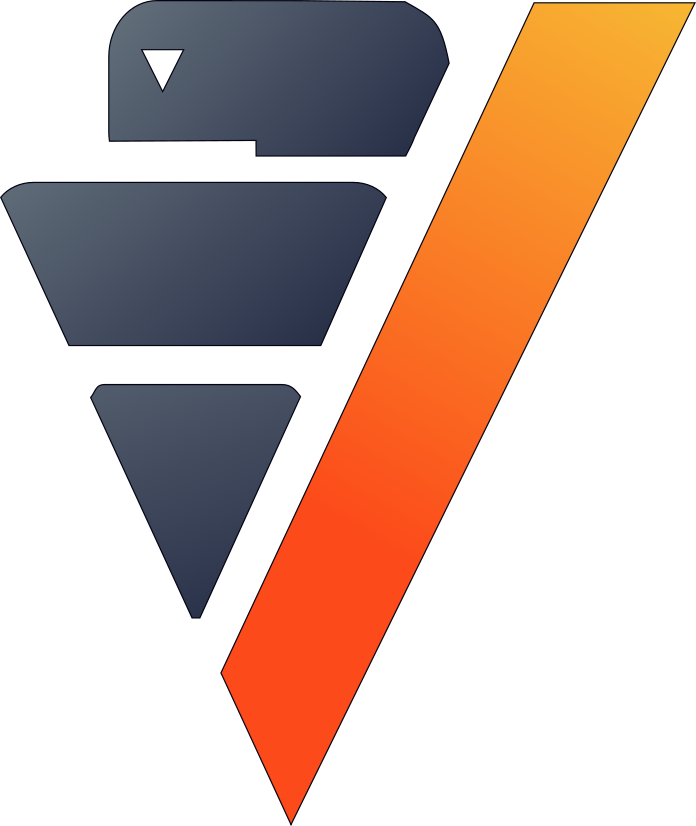

In [7]:
data["competition_stage"].astype("json")

As with a normal vDataFrame, we can easily extract the values from the sub-columns:

,Abcaway_team_genderVarchar(80)
1,male
2,male
3,male
4,male
5,male
6,male
7,male
8,male
9,male
10,male

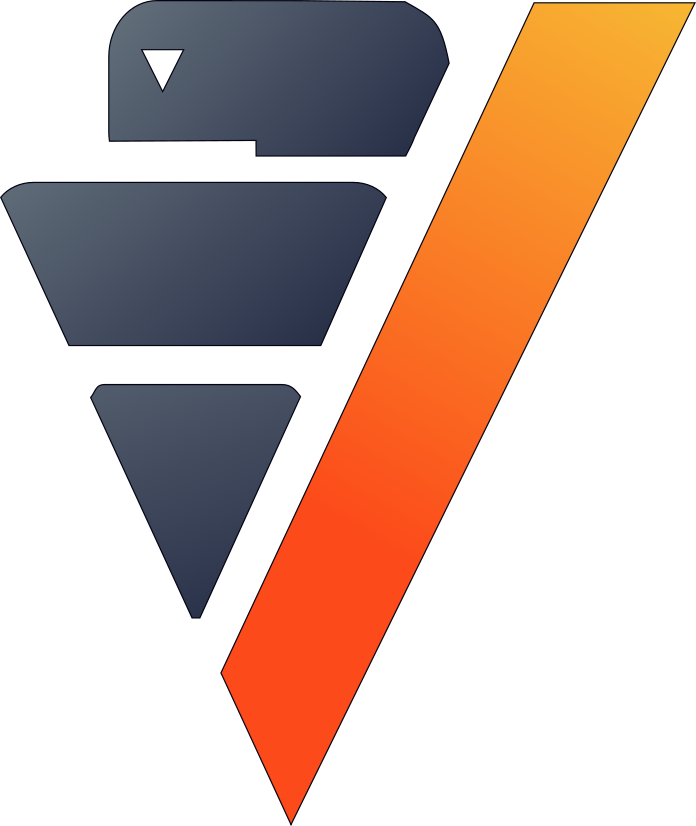

In [8]:
data["away_team"]["away_team_gender"]

We can view any nested data structure by index:

,123competition_idInteger
1,11
2,11
3,11
4,11
5,11
6,11
7,11
8,11
9,11
10,11

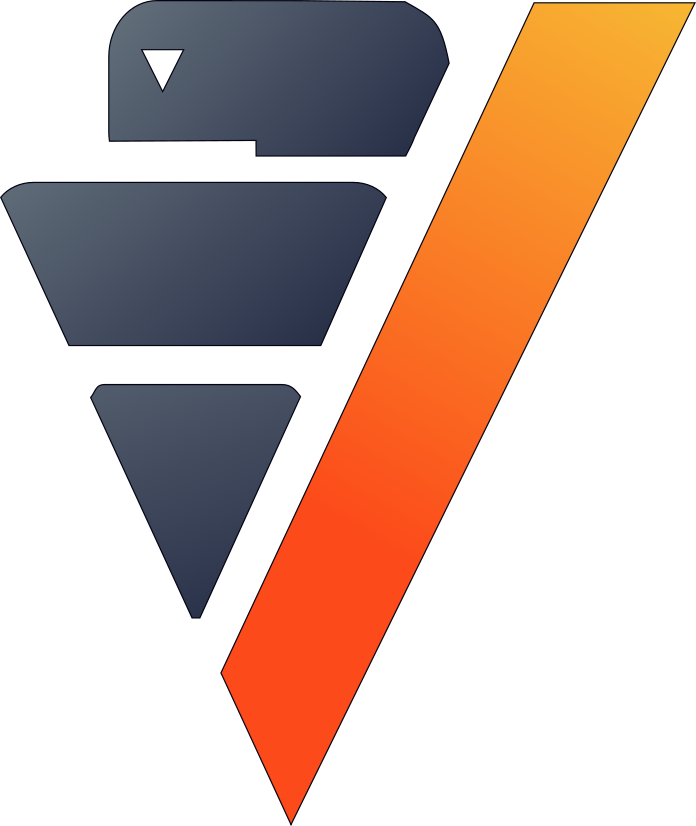

In [9]:
data["competition"]["competition_id"]

These nested structures can be used to create features:

In [10]:
data["name_home"] = data["home_team"]["home_team_name"]

We can even flatten the nested structure inside a json file, either flattening the entire file or just particular columns: 

The table "complex_vmap_test"."laliga_flat" has been successfully created.


,AbcVmap(368),AbcVmap(378),Abcseason.season_nameVarchar(20),123season.season_idInt,123metadata.xy_fidelity_versionInt,123metadata.shot_fidelity_versionInt,📅metadata.data_versionDate,123match_weekInt,Abcmatch_statusVarchar(20),123match_idInt,📅match_dateDate,📅last_updatedTimestamp,📅kick_offTime,Abchome_team.home_team_nameVarchar(34),123home_team.home_team_idInt,Abchome_team.home_team_groupVarchar(20),Abchome_team.home_team_genderVarchar(20),Abchome_team.country.nameVarchar(20),123home_team.country.idInt,123home_scoreInt,Abccompetition_stage.nameVarchar(28),123competition_stage.idInt,Abccompetition.country_nameVarchar(20),Abccompetition.competition_nameVarchar(20),123competition.competition_idInt,Abcaway_team.country.nameVarchar(20),123away_team.country.idInt,Abcaway_team.away_team_nameVarchar(38),123away_team.away_team_idInt,Abcaway_team.away_team_groupVarchar(20),Abcaway_team.away_team_genderVarchar(20),123away_scoreInt
1,,,2008/2009,41,2,2,2000-01-01,1,available,69147,2008-08-31,2019-12-16 23:09:16.168756,19:00:00,Numancia,444,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,0
2,,,2008/2009,41,2,2,2000-01-01,2,available,69215,2008-09-13,2019-12-16 23:09:16.168756,20:00:00,Barcelona,217,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Racing Santander,1217,[null],male,1
3,,,2008/2009,41,2,2,2000-01-01,3,available,69138,2008-09-21,2019-12-16 23:09:16.168756,21:00:00,Sporting Gijón,1041,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,6
4,,,2008/2009,41,2,2,2000-01-01,4,available,69207,2008-09-24,2019-12-16 23:09:16.168756,20:00:00,Barcelona,217,[null],male,Spain,214,3,Regular Season,1,Spain,La Liga,11,Spain,214,Real Betis,218,[null],male,2
5,,,2008/2009,41,2,2,2000-01-01,5,available,69211,2008-09-27,2019-12-16 23:09:16.168756,22:00:00,Espanyol,214,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
6,,,2008/2009,41,2,2,2000-01-01,6,available,69212,2008-10-04,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Atlético Madrid,212,[null],male,1
7,,,2008/2009,41,2,2,2000-01-01,8,available,69232,2008-10-25,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,5,Regular Season,1,Spain,La Liga,11,Spain,214,Almería,403,[null],male,0
8,,,2008/2009,41,2,2,2000-01-01,9,available,69235,2008-11-01,2019-12-16 23:09:16.168756,20:00:00,Málaga,223,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,4
9,,,2008/2009,41,2,2,2000-01-01,10,available,69279,2008-11-08,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Real Valladolid,901,[null],male,0
10,,,2008/2009,41,2,2,2000-01-01,11,available,69285,2008-11-16,2019-12-16 23:09:16.168756,21:00:00,Recreativo Huelva,1220,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2

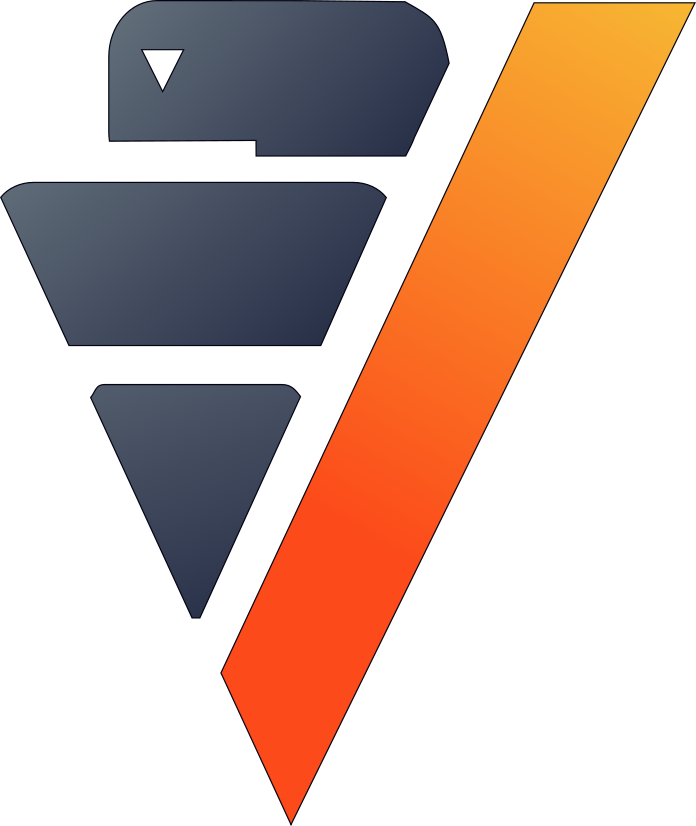

In [17]:
data = vp.read_json(path = path + "laliga/2008.json",
                    table_name = "laliga_flat",
                    schema = "complex_vmap_test",
                    ingest_local = False,
                    flatten_maps = True,)
data

We can see that all the columns from the JSON file have been flattened and multiple columns have been created for each sub-column. This causes some loss in data structure, but makes it easy to see the data and to use it for model building.

It is important to note that the data type of certain columns (home_team.managers) is now VMap, and not the ROW type that we saw in [the above cells](#row_cell). Even though both are used to capture nested data, there is in a subtle difference between the two. 

<b>VMap:</b> More flexible as it stores the data as a string of maps, allowing the ingestion of data in varying shapes. The shape is not fixed and new keys can easily be handled. This is a great option when we don't know the structure in advance, or if the structure changes over time.

<b>Row:</b> More rigid because the dictionaries, including all the data types, are fixed when they are defined. Newly parsed keys are ignored. But because of it's rigid structure, it is much more performant than VMaps. They are best used when the file structure is known in advance.

To deconvolve the nested structure, we can use the 'flatten_arrays' parameter in order to make the output strictly formatted. However, it can be an expensive process.

The table "complex_vmap_test"."laliga_flat" has been successfully created.


,Abchome_team.managers.0.nicknameVarchar(42),Abchome_team.managers.0.nameVarchar(64),123home_team.managers.0.idInt,📅home_team.managers.0.dobDate,AbcVarchar(20),123home_team.managers.0.country.idInt,Abcaway_team.managers.0.nicknameVarchar(42),AbcVarchar(72),123away_team.managers.0.idInt,📅away_team.managers.0.dobDate,AbcVarchar(20),123away_team.managers.0.country.idInt,Abcseason.season_nameVarchar(20),123season.season_idInt,123metadata.xy_fidelity_versionInt,123metadata.shot_fidelity_versionInt,📅metadata.data_versionDate,123match_weekInt,Abcmatch_statusVarchar(20),123match_idInt,📅match_dateDate,📅last_updatedTimestamp,📅kick_offTime,Abchome_team.home_team_nameVarchar(34),123home_team.home_team_idInt,Abchome_team.home_team_groupVarchar(20),Abchome_team.home_team_genderVarchar(20),Abchome_team.country.nameVarchar(20),123home_team.country.idInt,123home_scoreInt,Abccompetition_stage.nameVarchar(28),123competition_stage.idInt,Abccompetition.country_nameVarchar(20),Abccompetition.competition_nameVarchar(20),123competition.competition_idInt,Abcaway_team.country.nameVarchar(20),123away_team.country.idInt,Abcaway_team.away_team_nameVarchar(38),123away_team.away_team_idInt,Abcaway_team.away_team_groupVarchar(20),Abcaway_team.away_team_genderVarchar(20),123away_scoreInt
1,José Luis Mendilibar,José Luis Mendilibar Etxebarria,221,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,29,available,69273,2009-04-04,2019-12-16 23:09:16.168756,20:00:00,Real Valladolid,901,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,1
2,Juan Muñiz,Juan Ramón López Muñiz,2,1968-11-02,,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,21,available,69209,2009-02-01,2019-12-16 23:09:16.168756,17:00:00,Racing Santander,1217,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
3,Juande Ramos,Juan de la Cruz Ramos Cano,3899,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,34,available,69249,2009-05-02,2019-12-16 23:09:16.168756,20:00:00,Real Madrid,220,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,6
4,Lucas Alcaraz,Luis Lucas Alcaraz González,1612,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,11,available,69285,2008-11-16,2019-12-16 23:09:16.168756,21:00:00,Recreativo Huelva,1220,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
5,Manolo Jiménez,Manuel Enrique Jiménez Jiménez,1621,1964-01-26,,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,13,available,69171,2008-11-29,2019-12-16 23:09:16.168756,22:00:00,Sevilla,213,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3
6,Manuel Pellegrini,Manuel Luis Pellegrini Ripamonti,733,[null],,45,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,16,available,69228,2008-12-21,2019-12-16 23:09:16.168756,19:00:00,Villarreal,222,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
7,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,Javier Aguirre,,3196,[null],,147,2008/2009,41,2,2,2000-01-01,6,available,69212,2008-10-04,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Atlético Madrid,212,[null],male,1
8,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,Joaquín Caparrós,,497,1955-10-13,,214,2008/2009,41,2,2,2000-01-01,26,available,69216,2009-03-07,2019-12-16 23:09:16.168756,20:00:00,Barcelona,217,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Athletic Bilbao,215,[null],male,0
9,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,José Luis Mendilibar,,221,[null],,214,2008/2009,41,2,2,2000-01-01,10,available,69279,2008-11-08,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Real Valladolid,901,[null],male,0
10,Pep Guardio
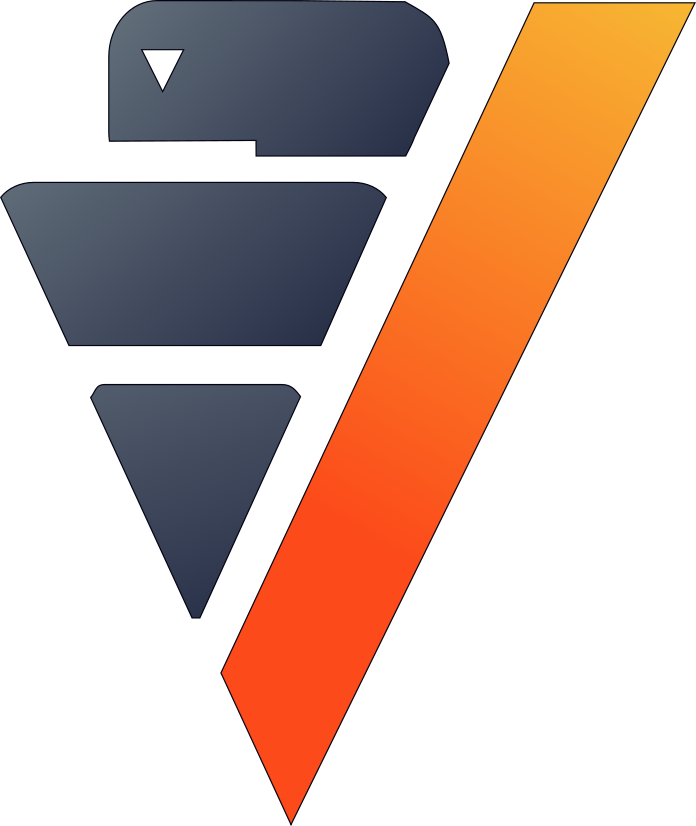

In [19]:
vp.drop("complex_vmap_test.laliga_flat")
data = vp.read_json(path = path + "laliga/2008.json",
                    table_name = "laliga_flat",
                    schema = "complex_vmap_test",
                    ingest_local = False,
                    flatten_arrays=True,)
data

We can even convert columns into other formats, such as string:

,Abchome_team.managers.0.nicknameVarchar,Abchome_team.managers.0.nameVarchar(64),123home_team.managers.0.idInt,📅home_team.managers.0.dobDate,AbcVarchar(20),123home_team.managers.0.country.idInt,Abcaway_team.managers.0.nicknameVarchar(42),AbcVarchar(72),123away_team.managers.0.idInt,📅away_team.managers.0.dobDate,AbcVarchar(20),123away_team.managers.0.country.idInt,Abcseason.season_nameVarchar(20),123season.season_idInt,123metadata.xy_fidelity_versionInt,123metadata.shot_fidelity_versionInt,📅metadata.data_versionDate,123match_weekInt,Abcmatch_statusVarchar(20),123match_idInt,📅match_dateDate,📅last_updatedTimestamp,📅kick_offTime,Abchome_team.home_team_nameVarchar(34),123home_team.home_team_idInt,Abchome_team.home_team_groupVarchar(20),Abchome_team.home_team_genderVarchar(20),Abchome_team.country.nameVarchar(20),123home_team.country.idInt,123home_scoreInt,Abccompetition_stage.nameVarchar(28),123competition_stage.idInt,Abccompetition.country_nameVarchar(20),Abccompetition.competition_nameVarchar(20),123competition.competition_idInt,Abcaway_team.country.nameVarchar(20),123away_team.country.idInt,Abcaway_team.away_team_nameVarchar(38),123away_team.away_team_idInt,Abcaway_team.away_team_groupVarchar(20),Abcaway_team.away_team_genderVarchar(20),123away_scoreInt
1,José Luis Mendilibar,José Luis Mendilibar Etxebarria,221,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,29,available,69273,2009-04-04,2019-12-16 23:09:16.168756,20:00:00,Real Valladolid,901,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,1
2,Juan Muñiz,Juan Ramón López Muñiz,2,1968-11-02,,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,21,available,69209,2009-02-01,2019-12-16 23:09:16.168756,17:00:00,Racing Santander,1217,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
3,Juande Ramos,Juan de la Cruz Ramos Cano,3899,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,34,available,69249,2009-05-02,2019-12-16 23:09:16.168756,20:00:00,Real Madrid,220,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,6
4,Lucas Alcaraz,Luis Lucas Alcaraz González,1612,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,11,available,69285,2008-11-16,2019-12-16 23:09:16.168756,21:00:00,Recreativo Huelva,1220,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
5,Manolo Jiménez,Manuel Enrique Jiménez Jiménez,1621,1964-01-26,,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,13,available,69171,2008-11-29,2019-12-16 23:09:16.168756,22:00:00,Sevilla,213,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3
6,Manuel Pellegrini,Manuel Luis Pellegrini Ripamonti,733,[null],,45,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,16,available,69228,2008-12-21,2019-12-16 23:09:16.168756,19:00:00,Villarreal,222,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
7,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,Javier Aguirre,,3196,[null],,147,2008/2009,41,2,2,2000-01-01,6,available,69212,2008-10-04,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Atlético Madrid,212,[null],male,1
8,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,Joaquín Caparrós,,497,1955-10-13,,214,2008/2009,41,2,2,2000-01-01,26,available,69216,2009-03-07,2019-12-16 23:09:16.168756,20:00:00,Barcelona,217,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Athletic Bilbao,215,[null],male,0
9,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,José Luis Mendilibar,,221,[null],,214,2008/2009,41,2,2,2000-01-01,10,available,69279,2008-11-08,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Real Valladolid,901,[null],male,0
10,Pep Guardiola,J
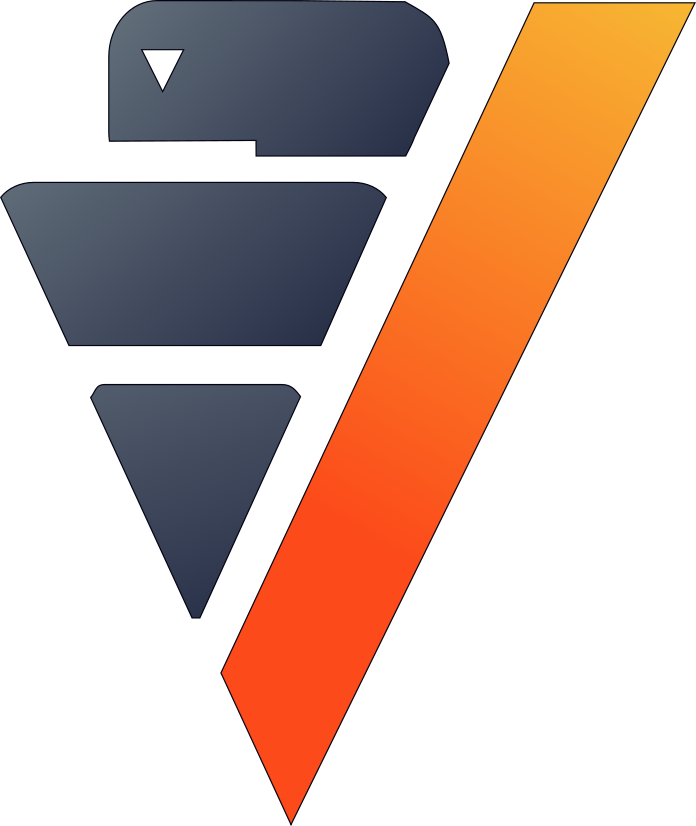

In [20]:
data["home_team.managers.0.nickname"].astype(str)

Or integer:

,Abchome_team.managers.0.nicknameVarchar,Abchome_team.managers.0.nameVarchar(64),123home_team.managers.0.idInt,📅home_team.managers.0.dobDate,AbcVarchar(20),123home_team.managers.0.country.idInt,Abcaway_team.managers.0.nicknameVarchar(42),AbcVarchar(72),123away_team.managers.0.idInt,📅away_team.managers.0.dobDate,AbcVarchar(20),123away_team.managers.0.country.idInt,Abcseason.season_nameVarchar(20),123season.season_idInt,123metadata.xy_fidelity_versionInt,123metadata.shot_fidelity_versionInt,📅metadata.data_versionDate,123match_weekInt,Abcmatch_statusVarchar(20),123match_idInt,📅match_dateDate,📅last_updatedTimestamp,📅kick_offTime,Abchome_team.home_team_nameVarchar(34),123home_team.home_team_idInt,Abchome_team.home_team_groupVarchar(20),Abchome_team.home_team_genderVarchar(20),Abchome_team.country.nameVarchar(20),123home_team.country.idInt,123home_scoreInt,Abccompetition_stage.nameVarchar(28),123competition_stage.idInt,Abccompetition.country_nameVarchar(20),Abccompetition.competition_nameVarchar(20),123competition.competition_idInt,Abcaway_team.country.nameVarchar(20),123away_team.country.idInt,Abcaway_team.away_team_nameVarchar(38),123away_team.away_team_idInt,Abcaway_team.away_team_groupVarchar(20),Abcaway_team.away_team_genderVarchar(20),123away_scoreInt
1,José Luis Mendilibar,José Luis Mendilibar Etxebarria,221,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,29,available,69273,2009-04-04,2019-12-16 23:09:16.168756,20:00:00,Real Valladolid,901,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,1
2,Juan Muñiz,Juan Ramón López Muñiz,2,1968-11-02,,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,21,available,69209,2009-02-01,2019-12-16 23:09:16.168756,17:00:00,Racing Santander,1217,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
3,Juande Ramos,Juan de la Cruz Ramos Cano,3899,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,34,available,69249,2009-05-02,2019-12-16 23:09:16.168756,20:00:00,Real Madrid,220,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,6
4,Lucas Alcaraz,Luis Lucas Alcaraz González,1612,[null],,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,11,available,69285,2008-11-16,2019-12-16 23:09:16.168756,21:00:00,Recreativo Huelva,1220,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
5,Manolo Jiménez,Manuel Enrique Jiménez Jiménez,1621,1964-01-26,,214,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,13,available,69171,2008-11-29,2019-12-16 23:09:16.168756,22:00:00,Sevilla,213,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3
6,Manuel Pellegrini,Manuel Luis Pellegrini Ripamonti,733,[null],,45,Pep Guardiola,,36,[null],,214,2008/2009,41,2,2,2000-01-01,16,available,69228,2008-12-21,2019-12-16 23:09:16.168756,19:00:00,Villarreal,222,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
7,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,Javier Aguirre,,3196,[null],,147,2008/2009,41,2,2,2000-01-01,6,available,69212,2008-10-04,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Atlético Madrid,212,[null],male,1
8,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,Joaquín Caparrós,,497,1955-10-13,,214,2008/2009,41,2,2,2000-01-01,26,available,69216,2009-03-07,2019-12-16 23:09:16.168756,20:00:00,Barcelona,217,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Athletic Bilbao,215,[null],male,0
9,Pep Guardiola,Josep Guardiola i Sala,36,[null],,214,José Luis Mendilibar,,221,[null],,214,2008/2009,41,2,2,2000-01-01,10,available,69279,2008-11-08,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,6,Regular Season,1,Spain,La Liga,11,Spain,214,Real Valladolid,901,[null],male,0
10,Pep Guardiola,J
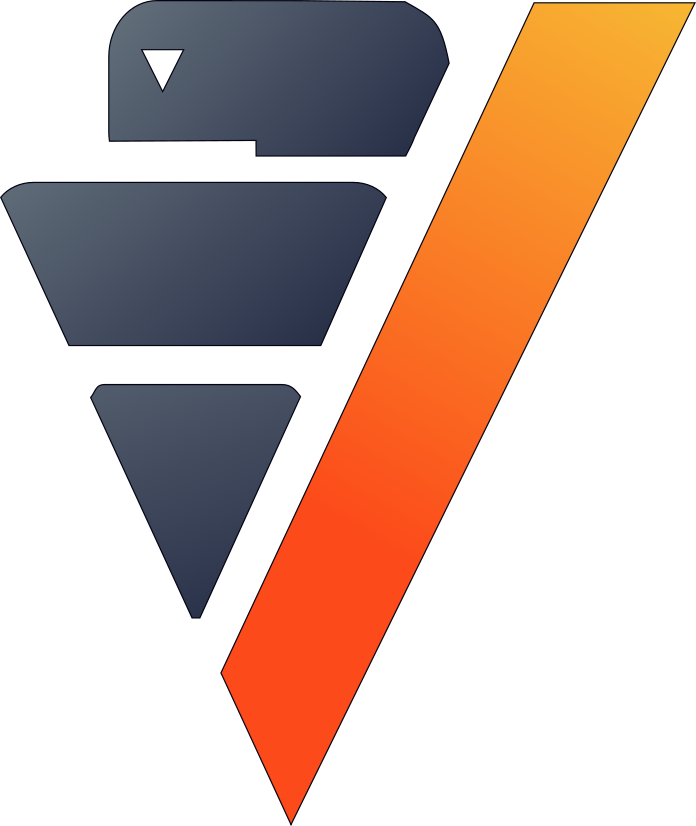

In [47]:
data["match_week"].astype(int)

It is also possible to:
<ul class="ul_content">
    <li>Cast str to array</li>
    <li>Cast complex data types to json str</li>
    <li>Cast str to VMAPs</li>
    <li>And much more...</li>
</ul>

## Multiple File Ingestion

If we have multiple files with the same extension, we can easily ingest them using the "*" operator:

,123away_scoreInt,"🛠Row(away_team_gender varchar(80),away_team_group varchar(80),away_team_id int,away_team_name varchar(80),country row(id int,name","🛠Row(competition_id int,competition_name varchar(80),country_name varchar(80))","🛠Row(id int,name varchar(80))",123home_scoreInt,"🛠Row(country row(id int,name varchar(80)),home_team_gender varchar(80),home_team_group varchar(80),home_team_id int,home_team_nam",📅kick_offTime,📅last_updatedDate,📅match_dateDate,123match_idInt,Abcmatch_statusVarchar(80),123match_weekInt,"🛠Row(data_version date,shot_fidelity_version int,xy_fidelity_version int)","🛠Row(season_id int,season_name varchar(80))"
1,0,,,,0,,19:00:00,2019-12-16,2014-05-11,266201,available,37,,
2,0,,,,0,,20:00:00,2019-12-16,2013-10-19,266462,available,9,,
3,0,,,,0,,22:00:00,2019-12-16,2011-10-22,69329,available,9,,
4,0,,,,0,,22:00:00,2019-12-16,2012-01-28,69338,available,21,,
5,0,,,,1,,19:00:00,2019-12-16,2008-08-31,69147,available,1,,
6,0,,,,1,,20:30:00,2019-12-16,2015-08-29,267422,available,2,,
7,0,,,,1,,20:45:00,2019-12-16,2016-10-29,267058,available,10,,
8,0,,,,1,,20:45:00,2019-12-16,2019-04-27,16289,available,35,,
9,0,,,,1,,21:00:00,2019-12-16,2013-11-01,70283,available,12,,
10,0,,,,1,,21:30:00,2019-12-16,2012-09-02,70286,available,3,,

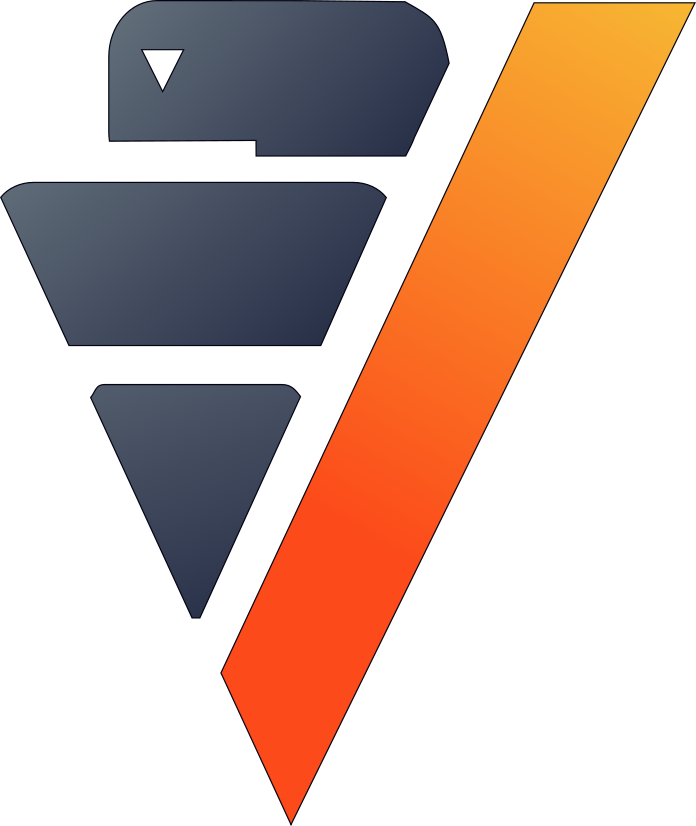

In [7]:
data = vp.read_file(path = path + "laliga/*.json",
                    table_name = "laliga_all",
                    ingest_local = False,
                    schema = "complex_vmap_test",)
data

We can also do this for other file types. For example, csv:

,AbcnameVarchar(38),AbcVarchar(90)
1,Abidjan,
2,Abidjan,
3,Abu Dhabi,
4,Abu Dhabi,
5,Abuja,
6,Abuja,
7,Accra,
8,Accra,
9,Addis Ababa,
10,Addis Ababa,

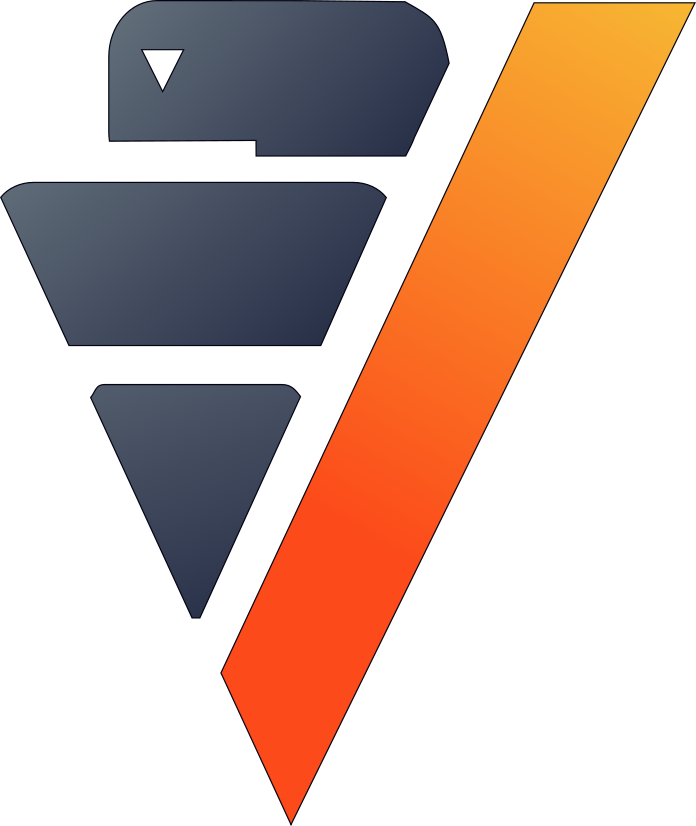

In [44]:
data = vp.read_csv(path = path + "*.csv",
                   table_name = "cities_all",
                   schema = "complex_vmap_test",
                   ingest_local = False,
                   insert = True)
data

Because we had copies of the same file, we can see that there are two records of each line. The ease of "*" allows us to ingest all the files in a particular folder.

## Materialize

When we do not materialize a table, it automatically becomes a flextable:

,123referee.country.idInteger,Abcreferee.country.nameVarchar(20),123stadium.country.idInteger,123referee.idInteger,123stadium.idInteger,Abcstadium.nameVarchar(64),Abcstadium.country.nameVarchar(26),Abcreferee.nameVarchar(46),AbcVmap(384),AbcVmap(378),123metadata.xy_fidelity_versionInteger,📅kick_offTime,Abchome_team.home_team_genderVarchar(20),123home_team.country.idInteger,Abccompetition.competition_nameVarchar(20),Abcaway_team.away_team_nameVarchar(38),Abcaway_team.away_team_genderVarchar(20),Abcseason.season_nameVarchar(20),📅metadata.data_versionDate,📅match_dateDate,Abchome_team.home_team_nameVarchar(40),123home_team.home_team_idInteger,Abchome_team.home_team_groupVarchar(20),123home_scoreInteger,Abccompetition_stage.nameVarchar(28),123competition.competition_idInteger,Abcaway_team.country.nameVarchar(20),123season.season_idInteger,123match_weekInteger,Abcmatch_statusVarchar(20),📅last_updatedTimestamp,Abchome_team.country.nameVarchar(20),123competition_stage.idInteger,123away_team.country.idInteger,Abcaway_team.away_team_groupVarchar(20),123away_scoreInteger,123metadata.shot_fidelity_versionInteger,123match_idInteger,Abccompetition.country_nameVarchar(20),123away_team.away_team_idInteger
1,[null],[null],[null],[null],[null],[null],[null],[null],,,2,21:00:00.000,male,214,La Liga,Getafe,male,2004/2005,1.1.0,2005-04-17,Barcelona,217,[null],2,Regular Season,11,Spain,37,32,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68352,Spain,216
2,[null],[null],[null],[null],[null],[null],[null],[null],,,2,22:00:00.000,male,214,La Liga,Barcelona,male,2004/2005,1.1.0,2004-10-16,Espanyol,214,[null],0,Regular Season,11,Spain,37,7,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],1,2,68353,Spain,217
3,[null],[null],[null],[null],[null],[null],[null],[null],,,2,19:00:00.000,male,214,La Liga,Albacete,male,2004/2005,1.1.0,2005-05-01,Barcelona,217,[null],2,Regular Season,11,Spain,37,34,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68316,Spain,608
4,[null],[null],[null],[null],[null],[null],[null],[null],,,2,20:00:00.000,male,214,La Liga,Levante,male,2004/2005,1.1.0,2004-12-21,Barcelona,217,[null],2,Regular Season,11,Spain,37,17,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],1,2,68315,Spain,221
5,[null],[null],[null],[null],[null],[null],[null],[null],,,2,20:00:00.000,male,214,La Liga,Málaga,male,2004/2005,1.1.0,2004-12-04,Barcelona,217,[null],4,Regular Season,11,Spain,37,14,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68314,Spain,223
6,[null],[null],[null],[null],[null],[null],[null],[null],,,2,21:00:00.000,male,214,La Liga,Osasuna,male,2004/2005,1.1.0,2004-10-24,Barcelona,217,[null],3,Regular Season,11,Spain,37,8,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68313,Spain,422
7,[null],[null],[null],[null],[null],[null],[null],[null],,,2,20:00:00.000,male,214,La Liga,Barcelona,male,2004/2005,1.1.0,2004-12-11,Albacete,608,[null],1,Regular Season,11,Spain,37,15,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],2,2,69153,Spain,217
8,[null],[null],[null],[null],[null],[null],[null],[null],,,2,21:00:00.000,male,214,La Liga,Racing Santander,male,2005/2006,1.1.0,2005-11-27,Barcelona,217,[null],4,Regular Season,11,Spain,38,13,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],1,2,68354,Spain,1217
9,[null],[null],[null],[null],[null],[null],[null],[null],,,2,22:00:00.000,male,214,La Liga,Barcelona,male,2005/2006,1.1.0,2006-02-25,Real Zaragoza,395,[null],0,Regular Season,11,Spain,38,25,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],2,2,68351,Spain,217
10,[null],[null],[null],[null],[null],[null],[null],[null],,,2,19:00:00.000,male,214,La Liga,Atlético Madrid,male,2005/2006,1.1.0,2006-02-05,Barcelona,217,[null],1,Regular Season,11,Spain,38,22,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],3,2,68350,Spain,212

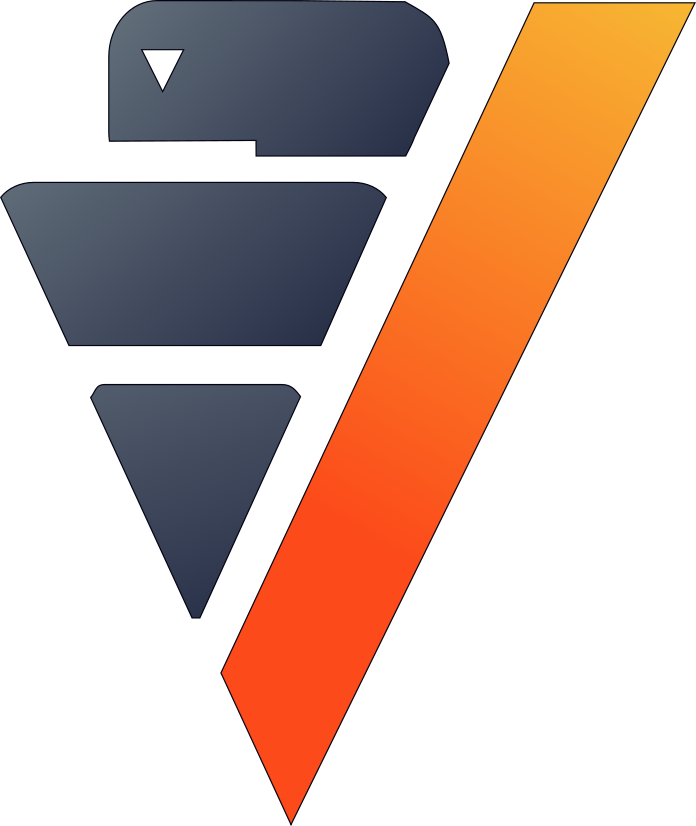

In [3]:
data = vp.read_json(path = path + "laliga/*.json",
                    table_name = "laliga_verticapy_test_json",
                    schema = "complex_vmap_test",
                    ingest_local = False,
                    materialize = False,)
data

Some of the columns are VMAPs:

In [11]:
managers = ["away_team.managers", "home_team.managers"]
for m in managers:
    print(data[m].isvmap())

True
True


We can easily flatten the VMaps virtual columns by using the vDataFrame.<a href="../../../documentation_last/vdataframe/main-methods/flat_vmap/index.php">flat_vmap</a> method:

,Abcreferee.country.idLong varchar(130000),Abcreferee.country.nameLong varchar(130000),Abcstadium.country.idLong varchar(130000),Abcreferee.idLong varchar(130000),Abcstadium.idLong varchar(130000),Abcstadium.nameLong varchar(130000),Abcstadium.country.nameLong varchar(130000),Abcreferee.nameLong varchar(130000),Abcmetadata.xy_fidelity_versionLong varchar(130000),Abckick_offLong varchar(130000),Abchome_team.home_team_genderLong varchar(130000),Abchome_team.country.idLong varchar(130000),Abccompetition.competition_nameLong varchar(130000),Abcaway_team.away_team_nameLong varchar(130000),Abcaway_team.away_team_genderLong varchar(130000),Abcseason.season_nameLong varchar(130000),Abcmetadata.data_versionLong varchar(130000),Abcmatch_dateLong varchar(130000),Abchome_team.home_team_nameLong varchar(130000),Abchome_team.home_team_idLong varchar(130000),Abchome_team.home_team_groupLong varchar(130000),Abchome_scoreLong varchar(130000),Abccompetition_stage.nameLong varchar(130000),Abccompetition.competition_idLong varchar(130000),Abcaway_team.country.nameLong varchar(130000),...,Abcseason.season_idLong varchar(130000),Abcmatch_weekLong varchar(130000),Abcmatch_statusLong varchar(130000),Abclast_updatedLong varchar(130000),Abchome_team.country.nameLong varchar(130000),Abccompetition_stage.idLong varchar(130000),Abcaway_team.country.idLong varchar(130000),Abcaway_team.away_team_groupLong varchar(130000),Abcaway_scoreLong varchar(130000),Abcmetadata.shot_fidelity_versionLong varchar(130000),Abcmatch_idLong varchar(130000),Abccompetition.country_nameLong varchar(130000),Abcaway_team.away_team_idLong varchar(130000),AbcLong varchar(130000),Abcaway_team.managers.0.idLong varchar(130000),AbcLong varchar(130000),Abcaway_team.managers.0.nicknameLong varchar(130000),Abcaway_team.managers.0.dobLong varchar(130000),Abcaway_team.managers.0.country.idLong varchar(130000),Abchome_team.managers.0.idLong varchar(130000),AbcLong varchar(130000),AbcLong varchar(130000),Abchome_team.managers.0.nicknameLong varchar(130000),Abchome_team.managers.0.dobLong varchar(130000),Abchome_team.managers.0.country.idLong varchar(130000)
1,[null],[null],[null],[null],[null],[null],[null],[null],2,21:00:00.000,male,214,La Liga,Getafe,male,2004/2005,1.1.0,2005-04-17,Barcelona,217,[null],2,Regular Season,11,Spain,...,37,32,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68352,Spain,216,,[null],,[null],[null],[null],[null],,,[null],[null],[null]
2,[null],[null],[null],[null],[null],[null],[null],[null],2,22:00:00.000,male,214,La Liga,Barcelona,male,2004/2005,1.1.0,2004-10-16,Espanyol,214,[null],0,Regular Season,11,Spain,...,37,7,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],1,2,68353,Spain,217,,[null],,[null],[null],[null],[null],,,[null],[null],[null]
3,[null],[null],[null],[null],[null],[null],[null],[null],2,19:00:00.000,male,214,La Liga,Albacete,male,2004/2005,1.1.0,2005-05-01,Barcelona,217,[null],2,Regular Season,11,Spain,...,37,34,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68316,Spain,608,,[null],,[null],[null],[null],[null],,,[null],[null],[null]
4,[null],[null],[null],[null],[null],[null],[null],[null],2,20:00:00.000,male,214,La Liga,Levante,male,2004/2005,1.1.0,2004-12-21,Barcelona,217,[null],2,Regular Season,11,Spain,...,37,17,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],1,2,68315,Spain,221,,[null],,[null],[null],[null],[null],,,[null],[null],[null]
5,[null],[null],[null],[null],[null],[null],[null],[null],2,20:00:00.000,male,214,La Liga,Málaga,male,2004/2005,1.1.0,2004-12-04,Barcelona,217,[null],4,Regular Season,11,Spain,...,37,14,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68314,Spain,223,,[null],,[null],[null],[null],[null],,,[null],[null],[null]
6,[null],[null],[null],[null],[null],[null],[null],[null],2,21:00:00.000,male,214,La Liga,Osasuna,male,2004/2005,1.1.0,2004-10-24,Barcelona,217,[null],3,Regular Season,11,Spain,...,37,8,available,2019-12-16T23:09:16.168756,Spain,1,214,[null],0,2,68313,Spai
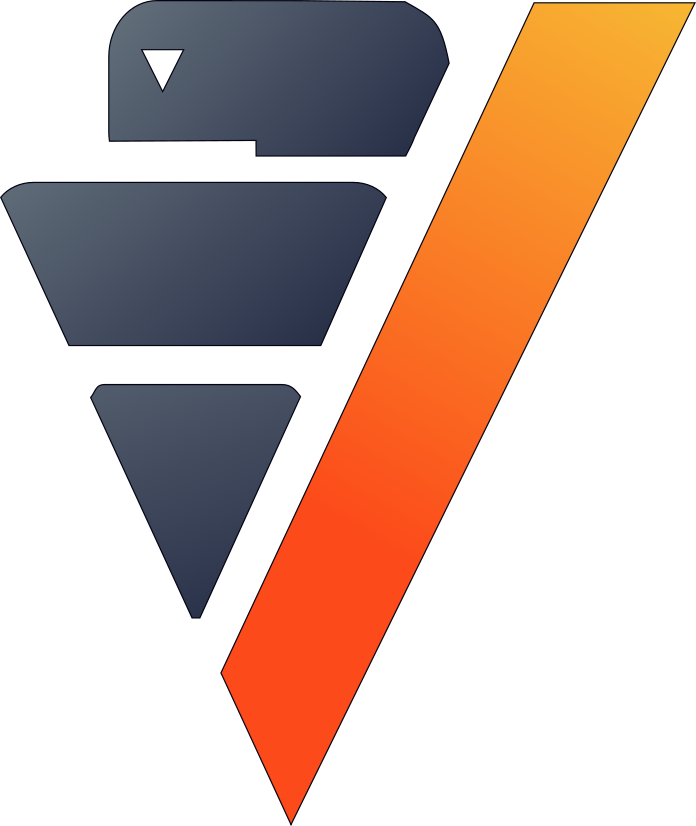

In [5]:
data.flat_vmap(managers).drop(managers)

To check for a flex table, we can use the following function:

In [46]:
isflextable(table_name = "laliga_verticapy_test_json", schema = "complex_vmap_test")

True

We can then manually materialize the flextable using the convenient vDataFrame.<a href="../../../documentation_last/vdataframe/main-methods/to_db/index.php">to_db</a> method:

,Abcseason.season_nameVarchar(20),123season.season_idInteger,123metadata.xy_fidelity_versionInteger,123metadata.shot_fidelity_versionInteger,📅metadata.data_versionDate,123match_weekInteger,Abcmatch_statusVarchar(20),123match_idInteger,📅match_dateDate,📅last_updatedTimestamp,📅kick_offTime,Abchome_team.home_team_nameVarchar(26),123home_team.home_team_idInteger,Abchome_team.home_team_groupVarchar(20),Abchome_team.home_team_genderVarchar(20),Abchome_team.country.nameVarchar(20),123home_team.country.idInteger,123home_scoreInteger,Abccompetition_stage.nameVarchar(28),123competition_stage.idInteger,Abccompetition.country_nameVarchar(20),Abccompetition.competition_nameVarchar(20),123competition.competition_idInteger,Abcaway_team.country.nameVarchar(20),123away_team.country.idInteger,Abcaway_team.away_team_nameVarchar(34),123away_team.away_team_idInteger,Abcaway_team.away_team_groupVarchar(20),Abcaway_team.away_team_genderVarchar(20),123away_scoreInteger
1,2005/2006,38,2,2,1.1.0,13,available,68354,2005-11-27,2019-12-16T23:09:16.168756,21:00:00.000,Barcelona,217,[null],male,Spain,214,4,Regular Season,1,Spain,La Liga,11,Spain,214,Racing Santander,1217,[null],male,1
2,2005/2006,38,2,2,1.1.0,25,available,68351,2006-02-25,2019-12-16T23:09:16.168756,22:00:00.000,Real Zaragoza,395,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
3,2005/2006,38,2,2,1.1.0,22,available,68350,2006-02-05,2019-12-16T23:09:16.168756,19:00:00.000,Barcelona,217,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Atlético Madrid,212,[null],male,3
4,2005/2006,38,2,2,1.1.0,19,available,68342,2006-01-15,2019-12-16T23:09:16.168756,19:00:00.000,Barcelona,217,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Athletic Bilbao,215,[null],male,1
5,2005/2006,38,2,2,1.1.0,15,available,68321,2005-12-11,2020-02-27T12:19:39.458017,21:00:00.000,Barcelona,217,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Sevilla,213,[null],male,1
6,2005/2006,38,2,2,1.1.0,18,available,68348,2006-01-07,2019-12-16T23:09:16.168756,22:00:00.000,Espanyol,214,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
7,2005/2006,38,2,2,1.1.0,10,available,68339,2005-11-06,2019-12-16T23:09:16.168756,21:00:00.000,Getafe,216,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3
8,2005/2006,38,2,2,1.1.0,12,available,68319,2005-11-19,2019-12-16T23:09:16.168756,20:00:00.000,Real Madrid,220,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3
9,2005/2006,38,2,2,1.1.0,8,available,68318,2005-10-22,2019-12-16T23:09:16.168756,22:00:00.000,Barcelona,217,[null],male,Spain,214,3,Regular Season,1,Spain,La Liga,11,Spain,214,Osasuna,422,[null],male,0
10,2005/2006,38,2,2,1.1.0,21,available,68325,2006-01-29,2019-12-16T23:09:16.168756,19:00:00.000,Mallorca,1043,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3

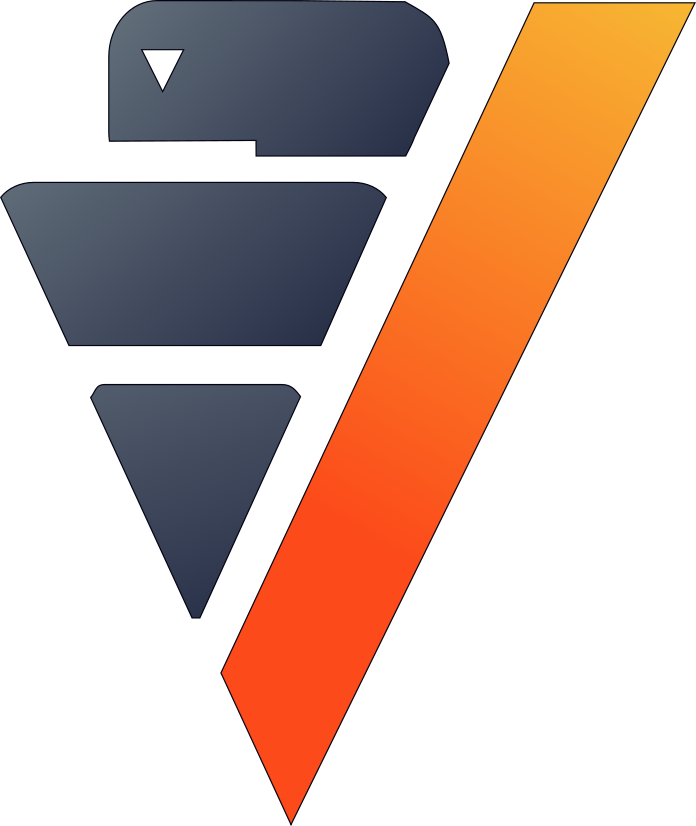

In [47]:
data.to_db("complex_vmap_test.laliga_to_db")

Once we have stored the database, we can easily create a vDataFrame of the relation:

,Abcseason.season_nameVarchar(20),123season.season_idInt,123metadata.xy_fidelity_versionInt,123metadata.shot_fidelity_versionInt,📅metadata.data_versionDate,123match_weekInt,Abcmatch_statusVarchar(20),123match_idInt,📅match_dateDate,📅last_updatedTimestamp,📅kick_offTime,Abchome_team.home_team_nameVarchar(26),123home_team.home_team_idInt,Abchome_team.home_team_groupVarchar(20),Abchome_team.home_team_genderVarchar(20),Abchome_team.country.nameVarchar(20),123home_team.country.idInt,123home_scoreInt,Abccompetition_stage.nameVarchar(28),123competition_stage.idInt,Abccompetition.country_nameVarchar(20),Abccompetition.competition_nameVarchar(20),123competition.competition_idInt,Abcaway_team.country.nameVarchar(20),123away_team.country.idInt,Abcaway_team.away_team_nameVarchar(34),123away_team.away_team_idInt,Abcaway_team.away_team_groupVarchar(20),Abcaway_team.away_team_genderVarchar(20),123away_scoreInt
1,2005/2006,38,2,2,2000-01-01,13,available,68354,2005-11-27,2019-12-16 23:09:16.168756,21:00:00,Barcelona,217,[null],male,Spain,214,4,Regular Season,1,Spain,La Liga,11,Spain,214,Racing Santander,1217,[null],male,1
2,2005/2006,38,2,2,2000-01-01,25,available,68351,2006-02-25,2019-12-16 23:09:16.168756,22:00:00,Real Zaragoza,395,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
3,2005/2006,38,2,2,2000-01-01,22,available,68350,2006-02-05,2019-12-16 23:09:16.168756,19:00:00,Barcelona,217,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Atlético Madrid,212,[null],male,3
4,2005/2006,38,2,2,2000-01-01,19,available,68342,2006-01-15,2019-12-16 23:09:16.168756,19:00:00,Barcelona,217,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Athletic Bilbao,215,[null],male,1
5,2005/2006,38,2,2,2000-01-01,15,available,68321,2005-12-11,2020-02-27 12:19:39.458017,21:00:00,Barcelona,217,[null],male,Spain,214,2,Regular Season,1,Spain,La Liga,11,Spain,214,Sevilla,213,[null],male,1
6,2005/2006,38,2,2,2000-01-01,18,available,68348,2006-01-07,2019-12-16 23:09:16.168756,22:00:00,Espanyol,214,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,2
7,2005/2006,38,2,2,2000-01-01,10,available,68339,2005-11-06,2019-12-16 23:09:16.168756,21:00:00,Getafe,216,[null],male,Spain,214,1,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3
8,2005/2006,38,2,2,2000-01-01,12,available,68319,2005-11-19,2019-12-16 23:09:16.168756,20:00:00,Real Madrid,220,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3
9,2005/2006,38,2,2,2000-01-01,8,available,68318,2005-10-22,2019-12-16 23:09:16.168756,22:00:00,Barcelona,217,[null],male,Spain,214,3,Regular Season,1,Spain,La Liga,11,Spain,214,Osasuna,422,[null],male,0
10,2005/2006,38,2,2,2000-01-01,21,available,68325,2006-01-29,2019-12-16 23:09:16.168756,19:00:00,Mallorca,1043,[null],male,Spain,214,0,Regular Season,1,Spain,La Liga,11,Spain,214,Barcelona,217,[null],male,3

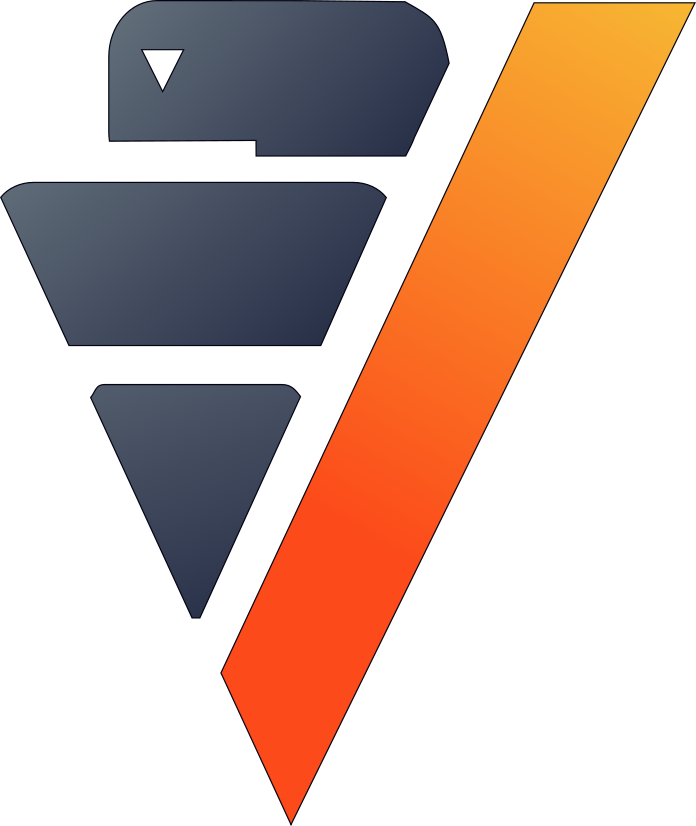

In [49]:
data_new = vp.vDataFrame("complex_vmap_test.laliga_to_db")
data_new

## Transformations

First, we load the dataset.

,AbcnameVarchar(38),AbcVarchar(90)
1,Abidjan,
2,Abu Dhabi,
3,Abuja,
4,Accra,
5,Addis Ababa,
6,Algiers,
7,Amman,
8,Amsterdam,
9,Andorra,
10,Ankara,

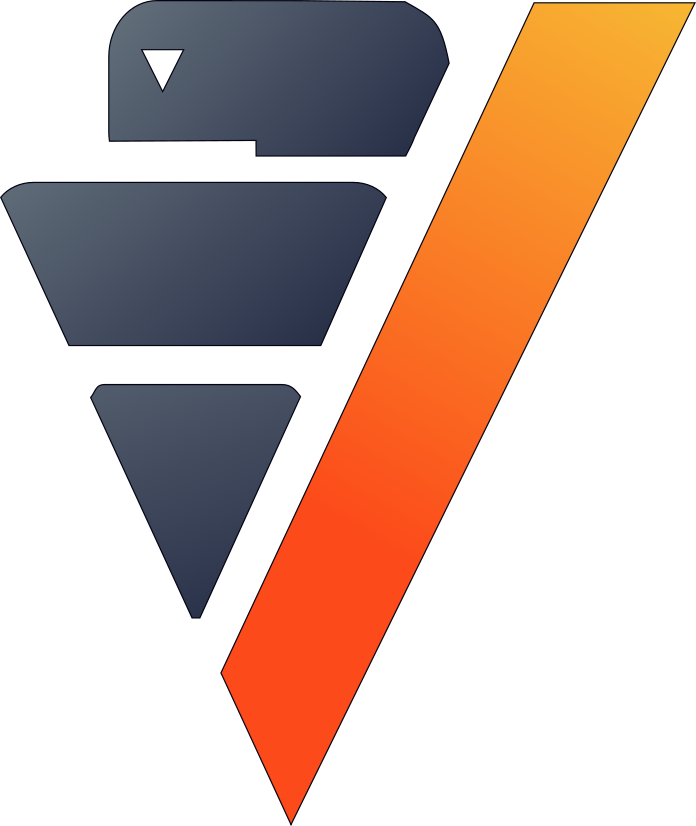

In [55]:
data = vp.read_csv(path = path + "cities.csv",
                   schema = "complex_vmap_test",
                   table_name = "cities_transf",
                   ingest_local = False,)
data

Once we have data in the form of vDataFrame, we can readily convert it to a JSON file:

In [56]:
data.to_json(path = "cities_json.json")

Now we can load the new JSON file and see the contents:


,AbcVarchar(90),AbcnameVarchar(38)
1,,London
2,,Accra
3,,Ouagadougou
4,,Monrovia
5,,Freetown
6,,Conakry
7,,Bissau
8,,Nouakchott
9,,Banjul
10,,Dakar

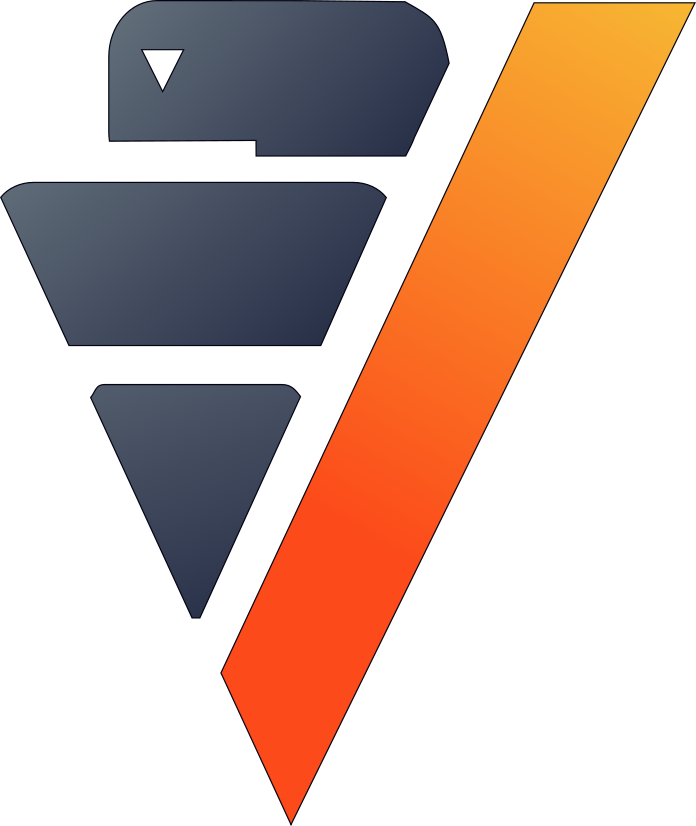

In [62]:
data = read_json(path = "cities_json.json",
                 schema = "complex_vmap_test",
                 table_name = "cities_transf_test",
                 ingest_local = False,)
data

We can even extract the JSON as string and edit it before saving it as a json file:

In [ ]:
json_str = data.to_json()

Let's look at the begining portion of the string:

In [67]:
json_str[0:100]

'[\n{"name": "Abidjan", "geometry": "POINT (-4.041994118507091 5.321942826098564)"},\n{"name": "Abu Dha'

We can edit a portion of the string and save it again. We'll change the name of the first city from Abidjan to Janabid:

In [68]:
json_str = json_str[:12] + 'JanAbid' + json_str[19:]

Now we can save this edited strings file:

In [ ]:
out_file = open("cities_edited.json", "w")
out_file.write(json_str)
out_file.close()

If we look at the new file, we can see the updated changes:

In [ ]:
data = vp.read_json(path = path + "cities_edited.json",
                    schema = "complex_vmap_test",
                    table_name = "cities_edit",
                    ingest_local = False,)

Let's search for the changed name:

,AbcVarchar(90),AbcnameVarchar(38)
1,,JanAbid

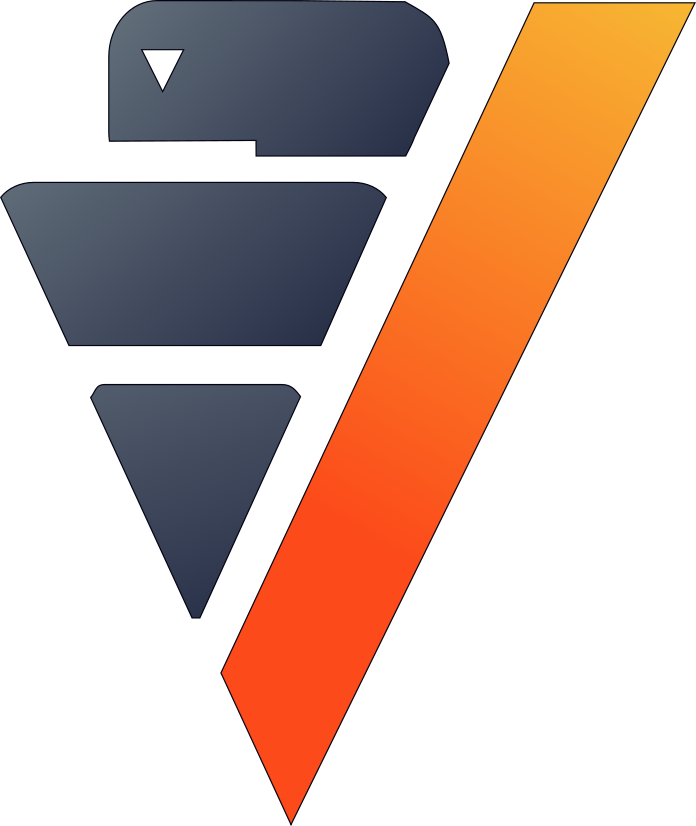

In [89]:
data[data["name"] == "JanAbid"]

Now to clean everything up, we can drop our temporary schema:

In [ ]:
vp.drop("complex_vmap_test", method = "schema")

## Conclusion

This new functionality not only make it easy to ingest complex data types in different formats, but it enables data wrangling like never before. 

The new features provide increased flexibility while keeping the process and syntax simple. You can do all of the following in VerticaPy:
<ul class="ul_content">
<li>Ingest complex datasets.</li>
<li>Perform convenient column operations.</li>
<li>Switch data types.</li>
<li>Flatten columns and maps into array like structures.</li>
</ul>